✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px


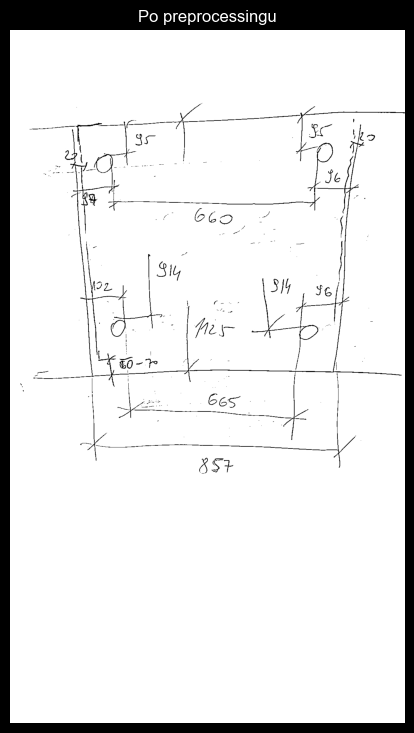

✓ Preprocessing OK

--- Krok 1: Thinning ---


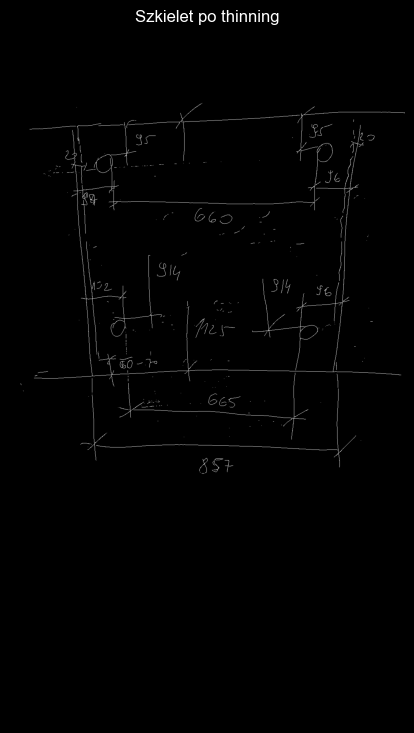

✓ Thinning OK

--- Krok 2: DeepLSD ---
✓ Model załadowany
DeepLSD wykrył: 256 surowych segmentów


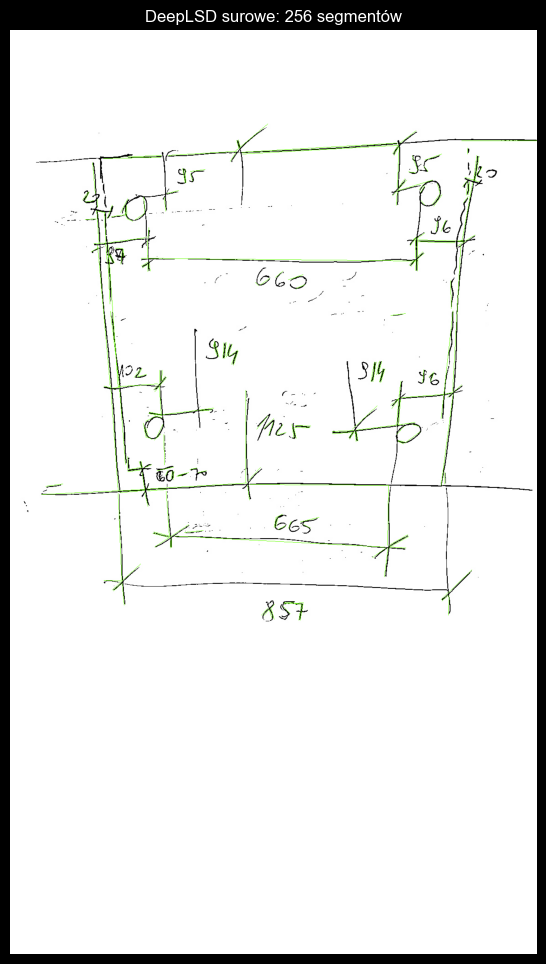


--- Krok 3: Klasyfikacja ---
main=22, wymiarowe=36, ticki=44


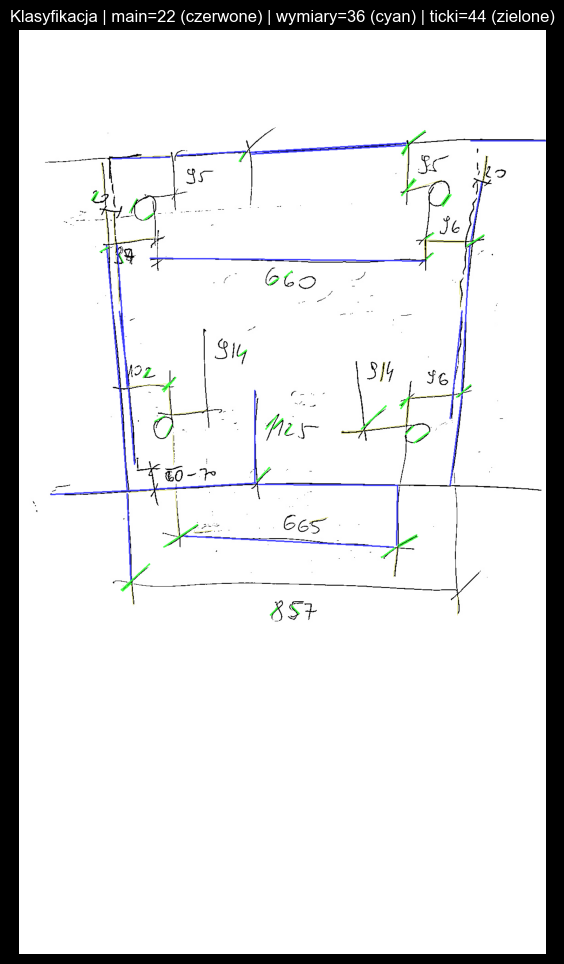


--- Krok 4: Prostokąt (skrajne H i V) ---
Linie poziome (main_h): 10
Linie pionowe (main_v): 12
  Górna:  Y=242  len=164.0px
  Dolna:  Y=1119  len=458.7px
  Lewa:   X=205  len=312.1px
  Prawa:  X=1000  len=128.1px
Prostokąt: (205,242)→(999,1119)  794x877px

--- Krok 5: Snap rogów do prostokąta ---
Snap: końce przyciągnięto do narożników (dist < 40px)

--- Krok 6: Okręgi ---
  mounting_1: (870,882)  r=28px  okrągłość=0.81
  mounting_2: (275,388)  r=28px  okrągłość=0.77
  mounting_3: (916,357)  r=28px  okrągłość=0.72
  mounting_4: (317,870)  r=25px  okrągłość=0.70


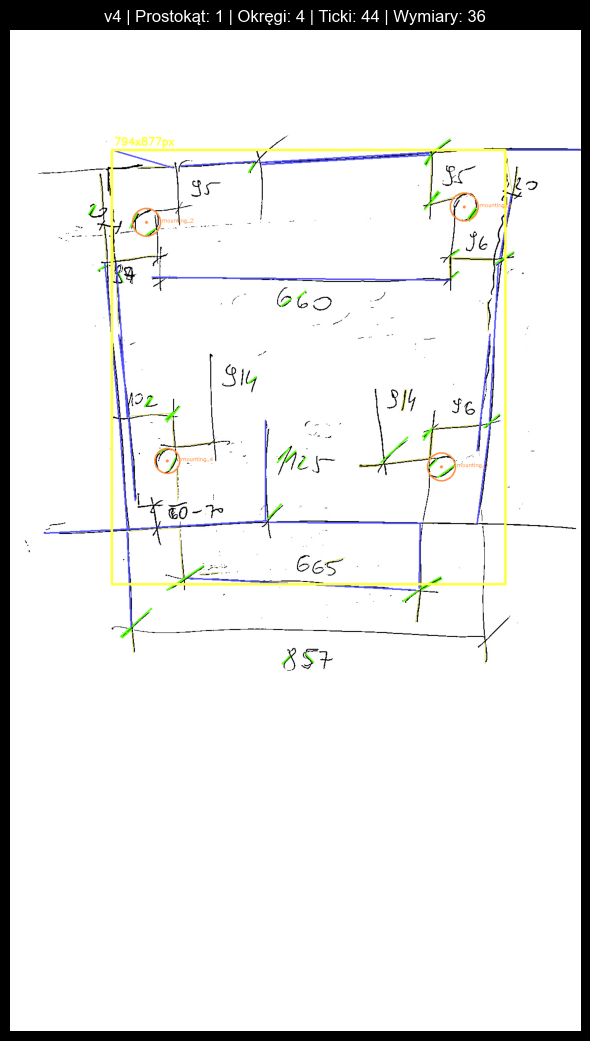


✅ Zapisano: C:\python\Intelligent_Sketch2CAD\intermediate_data\deeplsd_v4_20260511_091029.json
   Prostokąt: 1
   Okręgi montażowe: 4
   Linie wymiarowe: 36
   Ticki: 44

→ Gotowe do importu do FreeCAD


In [5]:
# -------------------------------
# SKETCH → CAD: DeepLSD v4 (prostokąt + snap rogów + okręgi)
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
import torch
import sys

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
DEEPLSD_DIR = PROJECT_DIR / "DeepLSD"
WEIGHTS_PATH = DEEPLSD_DIR / "weights" / "deeplsd_md.tar"

# -------------------------------
# LOAD IMAGE (adaptive_cleaned)
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# ============================================================
# PREPROCESSING (filtracja komponentów – identyczna jak w v2/v3)
# ============================================================
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    print(f"Main contour area: {cv2.contourArea(main_contour):.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    mask_near = cv2.dilate(mask_edge, np.ones((120, 120), np.uint8), iterations=1)

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)
    mask_final = np.zeros_like(gray, dtype=np.uint8)

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < 1500:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

plt.figure(figsize=(6, 9))
plt.imshow(gray, cmap='gray')
plt.title("Po preprocessingu")
plt.axis('off')
plt.show()
print("✓ Preprocessing OK")

# ============================================================
# 1. THINNING
# ============================================================
print("\n--- Krok 1: Thinning ---")
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
h, w = skeleton.shape

plt.figure(figsize=(6, 9))
plt.imshow(skeleton, cmap='gray')
plt.title("Szkielet po thinning")
plt.axis('off')
plt.show()
print("✓ Thinning OK")

# ============================================================
# 2. DeepLSD
# ============================================================
print("\n--- Krok 2: DeepLSD ---")
sys.path.insert(0, str(DEEPLSD_DIR))
from deeplsd.models.deeplsd_inference import DeepLSD

device = torch.device('cpu')
conf = {
    'detect_lines': True,
    'line_detection_params': {
        'merge': True,
        'filtering': True,
        'grad_thresh': 1,
        'grad_nfa': True,
    }
}

ckpt = torch.load(str(WEIGHTS_PATH), map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net.eval()
print("✓ Model załadowany")

img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    out = net({'image': img_tensor})

lines_raw = out['lines'][0]
print(f"DeepLSD wykrył: {len(lines_raw)} surowych segmentów")

all_segments = []
for line in lines_raw:
    x1, y1 = float(line[0][0]), float(line[0][1])
    x2, y2 = float(line[1][0]), float(line[1][1])
    length = np.hypot(x2 - x1, y2 - y1)
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
    all_segments.append((int(x1), int(y1), int(x2), int(y2), length, angle))

vis_raw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1, y1, x2, y2, length, angle) in all_segments:
    cv2.line(vis_raw, (x1, y1), (x2, y2), (0, 255, 100), 1)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.title(f"DeepLSD surowe: {len(all_segments)} segmentów")
plt.axis('off')
plt.show()

# ============================================================
# 3. KLASYFIKACJA (progi z v3: MIN_MAIN=80)
# ============================================================
print("\n--- Krok 3: Klasyfikacja ---")

ANGLE_TOL_STRAIGHT = 23
ANGLE_TOL_TICK = 19
MIN_MAIN = 100
MIN_DIM  = 40
MIN_TICK = 20
MAX_TICK = 90

def classify_segment(x1, y1, x2, y2, length, angle):
    is_horizontal = (angle < ANGLE_TOL_STRAIGHT or angle > (180 - ANGLE_TOL_STRAIGHT))
    is_vertical   = abs(angle - 90) < ANGLE_TOL_STRAIGHT
    is_straight   = is_horizontal or is_vertical
    is_tick_angle = (abs(angle - 45) < ANGLE_TOL_TICK or abs(angle - 135) < ANGLE_TOL_TICK)

    if is_straight and length >= MIN_MAIN:
        return "main"
    elif is_straight and length >= MIN_DIM:
        return "dimension_line"
    elif is_tick_angle and MIN_TICK <= length <= MAX_TICK:
        return "tick"
    elif length >= MIN_DIM:
        return "other"
    else:
        return "noise"

lines_main      = []
lines_dimension = []
lines_tick      = []
lines_other     = []

for seg in all_segments:
    x1, y1, x2, y2, length, angle = seg
    typ = classify_segment(x1, y1, x2, y2, length, angle)
    entry = {"x1": x1, "y1": y1, "x2": x2, "y2": y2,
             "length_px": round(length, 1), "angle_deg": round(angle, 1)}
    if typ == "main":
        lines_main.append(entry)
    elif typ == "dimension_line":
        lines_dimension.append(entry)
    elif typ == "tick":
        lines_tick.append(entry)
    elif typ == "other" and length > 150:
        lines_main.append(entry)   # długie ukośne traktuj jako krawędzie
    else:
        pass

print(f"main={len(lines_main)}, wymiarowe={len(lines_dimension)}, ticki={len(lines_tick)}")

vis_class = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (255, 60, 60), 2)
for l in lines_dimension:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60, 220, 220), 1)
for l in lines_tick:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60, 255, 60), 2)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_class, cv2.COLOR_BGR2RGB))
plt.title(f"Klasyfikacja | main={len(lines_main)} (czerwone) | wymiary={len(lines_dimension)} (cyan) | ticki={len(lines_tick)} (zielone)")
plt.axis('off')
plt.show()

# Zastąp tylko krok 4 — reszta kodu bez zmian

# ============================================================
# 4. PROSTOKĄT — skrajne H i V osobno
# ============================================================
print("\n--- Krok 4: Prostokąt (skrajne H i V) ---")

ANGLE_TOL = 20  # taka sama jak w klasyfikacji

# Rozdziel main na poziome i pionowe
main_h = [l for l in lines_main
          if l['angle_deg'] < ANGLE_TOL or l['angle_deg'] > (180 - ANGLE_TOL)]
main_v = [l for l in lines_main
          if abs(l['angle_deg'] - 90) < ANGLE_TOL]

print(f"Linie poziome (main_h): {len(main_h)}")
print(f"Linie pionowe (main_v): {len(main_v)}")

# Skrajne poziome: najmniejsze Y (górna) i największe Y (dolna)
# Skrajne pionowe: najmniejsze X (lewa) i największe X (prawa)
def mid_y(l): return (l['y1'] + l['y2']) / 2
def mid_x(l): return (l['x1'] + l['x2']) / 2

rectangles = []
if len(main_h) >= 2 and len(main_v) >= 2:
    top_line    = min(main_h, key=mid_y)
    bottom_line = max(main_h, key=mid_y)
    left_line   = min(main_v, key=mid_x)
    right_line  = max(main_v, key=mid_x)

    print(f"  Górna:  Y={mid_y(top_line):.0f}  len={top_line['length_px']}px")
    print(f"  Dolna:  Y={mid_y(bottom_line):.0f}  len={bottom_line['length_px']}px")
    print(f"  Lewa:   X={mid_x(left_line):.0f}  len={left_line['length_px']}px")
    print(f"  Prawa:  X={mid_x(right_line):.0f}  len={right_line['length_px']}px")

    x1 = int(mid_x(left_line))
    x2 = int(mid_x(right_line))
    y1 = int(mid_y(top_line))
    y2 = int(mid_y(bottom_line))

    rectangles.append({
        "label": "outer",
        "x1": x1, "y1": y1,
        "x2": x2, "y2": y2,
        "width_px":  x2 - x1,
        "height_px": y2 - y1
    })
    print(f"Prostokąt: ({x1},{y1})→({x2},{y2})  {x2-x1}x{y2-y1}px")
else:
    print("⚠ Za mało linii H lub V")

# ============================================================
# 5. SNAP KOŃCÓW LINII DO NAROŻY PROSTOKĄTA
# ============================================================
print("\n--- Krok 5: Snap rogów do prostokąta ---")

if rectangles:
    r = rectangles[0]
    corners = [(r['x1'], r['y1']), (r['x2'], r['y1']), (r['x2'], r['y2']), (r['x1'], r['y2'])]

    def snap_to_corners(lines, corners, snap_dist=30):
        """Przesuwa końce linii, które są w odległości < snap_dist od narożnika, dokładnie do narożnika."""
        snapped_lines = []
        for l in lines:
            x1, y1, x2, y2 = l['x1'], l['y1'], l['x2'], l['y2']
            for (cx, cy) in corners:
                if np.hypot(x1 - cx, y1 - cy) < snap_dist:
                    x1, y1 = cx, cy
                if np.hypot(x2 - cx, y2 - cy) < snap_dist:
                    x2, y2 = cx, cy
            snapped_lines.append({"x1": x1, "y1": y1, "x2": x2, "y2": y2,
                                  "length_px": l['length_px'], "angle_deg": l['angle_deg']})
        return snapped_lines

    lines_main_snapped = snap_to_corners(lines_main, corners, snap_dist=40)
    lines_dim_snapped   = snap_to_corners(lines_dimension, corners, snap_dist=40)
    lines_tick_snapped  = snap_to_corners(lines_tick, corners, snap_dist=40)

    print(f"Snap: końce przyciągnięto do narożników (dist < 40px)")
else:
    lines_main_snapped = lines_main
    lines_dim_snapped = lines_dimension
    lines_tick_snapped = lines_tick

# ============================================================
# 6. OKRĘGI (kontury + circularity) – jak w v3
# ============================================================
print("\n--- Krok 6: Okręgi ---")

kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)
circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles_all = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 300 or area > 12000:
        continue
    perimeter = cv2.arcLength(cnt, True)
    if perimeter < 1:
        continue
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.60:
        (cx, cy), radius = cv2.minEnclosingCircle(cnt)
        circles_all.append({
            "cx": int(cx), "cy": int(cy),
            "radius_px": int(radius),
            "circularity": round(circularity, 3)
        })

# Usuń duplikaty
circles_clean = []
for c in sorted(circles_all, key=lambda x: -x['radius_px']):
    if not any(np.hypot(c['cx']-e['cx'], c['cy']-e['cy']) < 25 for e in circles_clean):
        circles_clean.append(c)

circles_mounting = sorted(circles_clean, key=lambda x: -x['radius_px'])[:4]
for i, c in enumerate(circles_mounting):
    c['label'] = f"mounting_{i+1}"
    c['radius_mm'] = None
    print(f"  {c['label']}: ({c['cx']},{c['cy']})  r={c['radius_px']}px  okrągłość={c['circularity']:.2f}")

# ============================================================
# 7. WIZUALIZACJA KOŃCOWA
# ============================================================
vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Linie wymiarowe (cyan)
for l in lines_dim_snapped:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0, 200, 200), 1)
# Ticki (zielone)
for l in lines_tick_snapped:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0, 255, 80), 2)
# Linie główne (czerwone)
for l in lines_main_snapped:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (255, 80, 80), 2)
# Prostokąt (gruby żółty)
if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_final, (r['x1'],r['y1']), (r['x2'],r['y2']), (60, 255, 255), 3)
    cv2.putText(vis_final, f"{r['width_px']}x{r['height_px']}px", (r['x1']+5, r['y1']-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (60, 255, 255), 2)
# Okręgi (pomarańczowe)
for c in circles_mounting:
    cv2.circle(vis_final, (c['cx'],c['cy']), c['radius_px'], (60, 140, 255), 2)
    cv2.circle(vis_final, (c['cx'],c['cy']), 3, (60, 140, 255), -1)
    cv2.putText(vis_final, c['label'], (c['cx']+c['radius_px']+3, c['cy']),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (60, 140, 255), 1)

plt.figure(figsize=(9, 13))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"v4 | Prostokąt: {len(rectangles)} | Okręgi: {len(circles_mounting)} | Ticki: {len(lines_tick_snapped)} | Wymiary: {len(lines_dim_snapped)}")
plt.axis('off')
plt.show()

# ============================================================
# 8. ZAPIS JSON (z przyciętymi liniami i okręgami)
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "DeepLSD v4 (percentile rect + snap corners + circles from contours)",
    "rectangles": rectangles,
    "circles": circles_mounting,
    "lines": {
        "main": lines_main_snapped,
        "dimension_lines": lines_dim_snapped,
        "ticks": lines_tick_snapped,
    },
    "statistics": {
        "deeplsd_raw": len(all_segments),
        "main": len(lines_main),
        "dimension": len(lines_dimension),
        "ticks": len(lines_tick),
        "circles_found": len(circles_clean),
        "circles_mounting": len(circles_mounting)
    },
    "notes": {
        "radius_mm": "uzupełnij ręcznie lub skalibruj",
        "scale_hint": "857mm = szerokość zewnętrzna — użyj do kalibracji px→mm"
    }
}

json_path = INTERMEDIATE_DIR / f"deeplsd_v4_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

print(f"\n✅ Zapisano: {json_path}")
print(f"   Prostokąt: {len(rectangles)}")
print(f"   Okręgi montażowe: {len(circles_mounting)}")
print(f"   Linie wymiarowe: {len(lines_dim_snapped)}")
print(f"   Ticki: {len(lines_tick_snapped)}")
print("\n→ Gotowe do importu do FreeCAD")

✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg


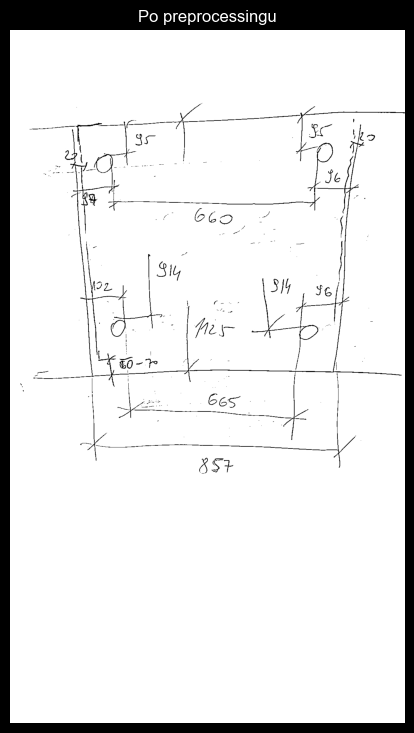

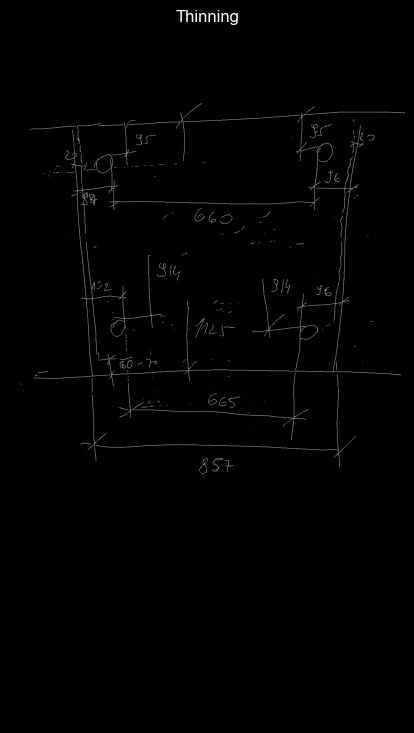

✓ Thinning OK

--- DeepLSD ---
✓ Model załadowany
DeepLSD: 344 segmentów


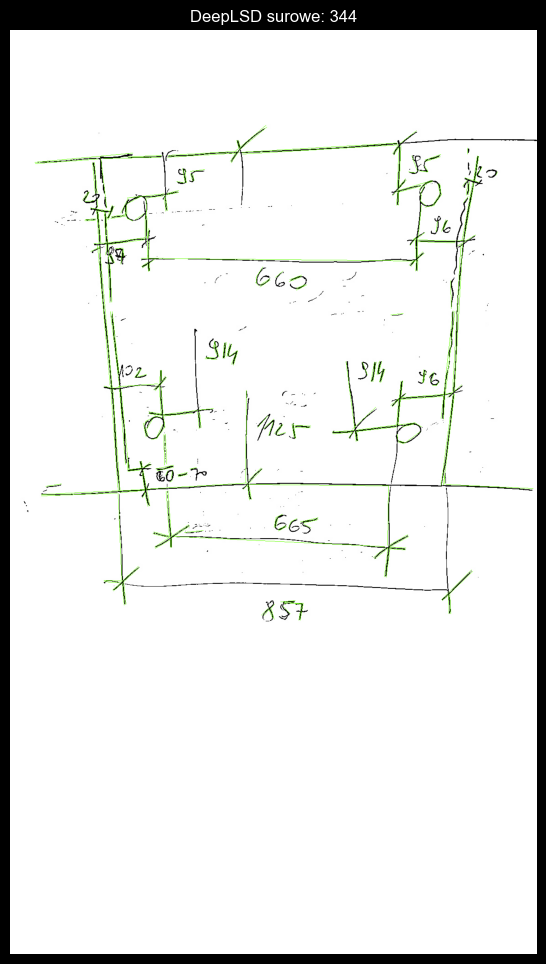


--- Klasyfikacja ---
main=54, wymiary=38, ticki=53


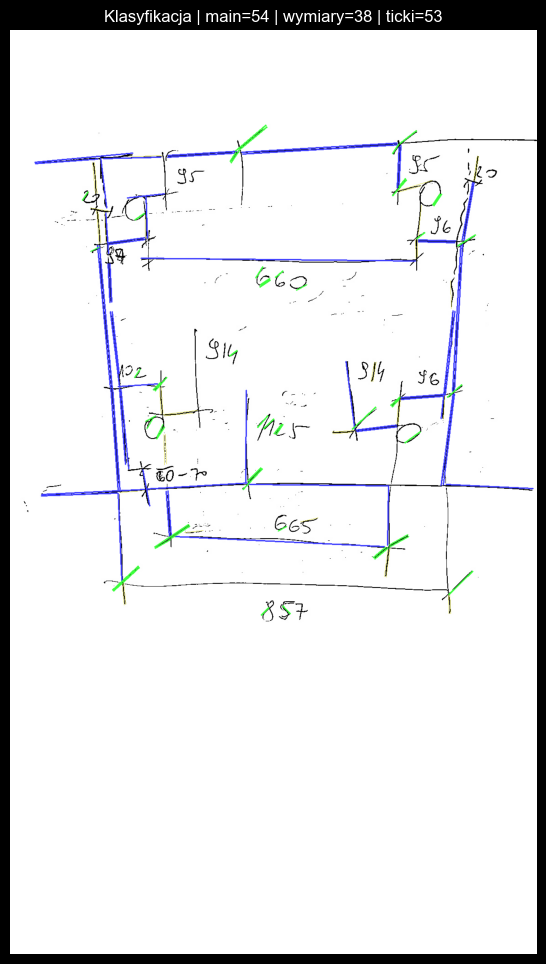


--- Krok 4: Prostokąt (skrajne H i V) ---
Linie poziome (main_h): 24
Linie pionowe (main_v): 30
  Górna:  Y=257  len=339.6px
  Dolna:  Y=1119  len=458.6px
  Lewa:   X=204  len=109.8px
  Prawa:  X=1003  len=128.1px
Prostokąt: (204,257)→(1003,1119)  799x862px


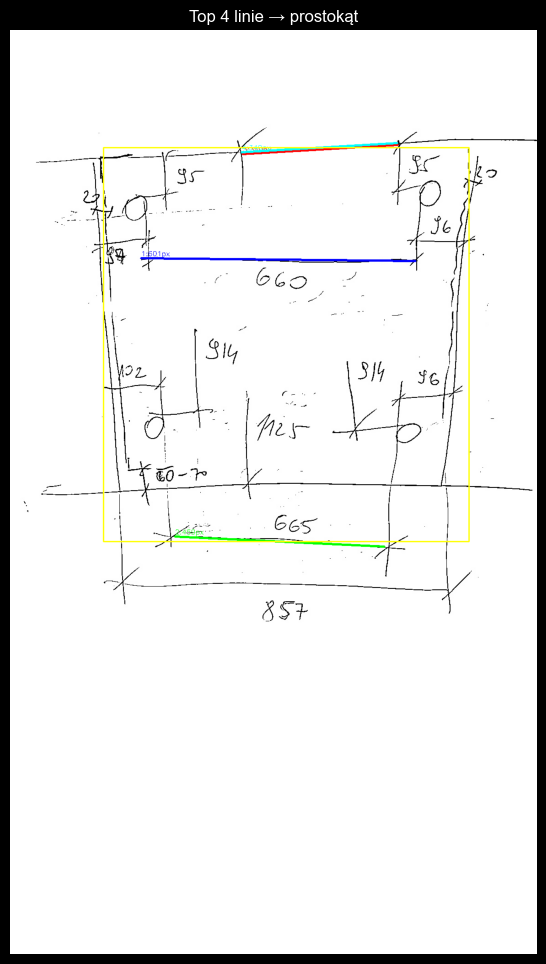


--- Okręgi ---
  mounting_1: (870,882)  r=28px
  mounting_2: (275,388)  r=28px
  mounting_3: (916,357)  r=28px
  mounting_4: (317,870)  r=25px

--- Wizualizacja końcowa ---


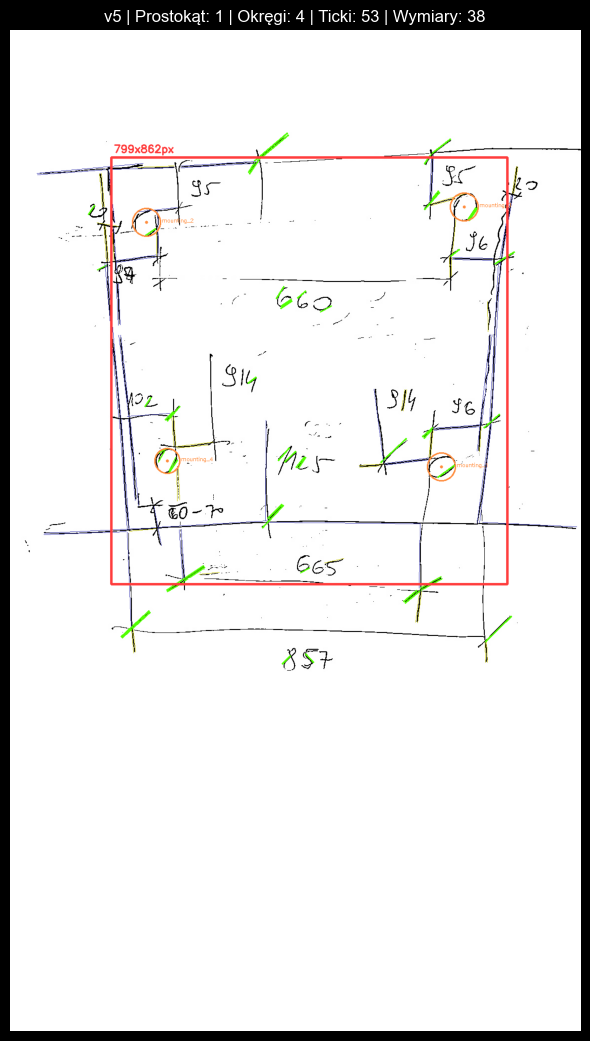


✅ C:\python\Intelligent_Sketch2CAD\intermediate_data\deeplsd_v5_20260511_091240.json
   Prostokąt: 1 | Okręgi: 4 | Ticki: 53 | Wymiary: 38

→ Następny krok: eksport DXF


In [6]:
# -------------------------------
# SKETCH → CAD: DeepLSD v5
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
import torch
import sys

print("✓ Ready")

PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
DEEPLSD_DIR = PROJECT_DIR / "DeepLSD"
WEIGHTS_PATH = DEEPLSD_DIR / "weights" / "deeplsd_md.tar"

pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# PREPROCESSING
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)
    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    mask_near = cv2.dilate(mask_edge, np.ones((120, 120), np.uint8), iterations=1)
    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)
    mask_final = np.zeros_like(gray, dtype=np.uint8)
    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < 1500:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

plt.figure(figsize=(6, 9))
plt.imshow(gray, cmap='gray'); plt.title("Po preprocessingu"); plt.axis('off'); plt.show()

# THINNING
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
h, w = skeleton.shape
plt.figure(figsize=(6, 9))
plt.imshow(skeleton, cmap='gray'); plt.title("Thinning"); plt.axis('off'); plt.show()
print("✓ Thinning OK")

# DEEPLSD
print("\n--- DeepLSD ---")
sys.path.insert(0, str(DEEPLSD_DIR))
from deeplsd.models.deeplsd_inference import DeepLSD

device = torch.device('cpu')
conf = {
    'detect_lines': True,
    'line_detection_params': {
        'merge': True, 'filtering': True,
        'grad_thresh': 2, 'grad_nfa': True,
    }
}
ckpt = torch.load(str(WEIGHTS_PATH), map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net.eval()
print("✓ Model załadowany")

img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
with torch.no_grad():
    out = net({'image': img_tensor})

lines_raw = out['lines'][0]
print(f"DeepLSD: {len(lines_raw)} segmentów")

all_segments = []
for line in lines_raw:
    x1, y1 = float(line[0][0]), float(line[0][1])
    x2, y2 = float(line[1][0]), float(line[1][1])
    length = np.hypot(x2-x1, y2-y1)
    angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
    all_segments.append((int(x1), int(y1), int(x2), int(y2), length, angle))

vis_raw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1,y1,x2,y2,l,a) in all_segments:
    cv2.line(vis_raw, (x1,y1), (x2,y2), (0,255,100), 1)
plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.title(f"DeepLSD surowe: {len(all_segments)}")
plt.axis('off'); plt.show()

# KLASYFIKACJA
print("\n--- Klasyfikacja ---")
ANGLE_TOL_STRAIGHT = 20
ANGLE_TOL_TICK = 18
MIN_MAIN = 80
MIN_DIM  = 40
MIN_TICK = 20
MAX_TICK = 90

def classify_segment(x1, y1, x2, y2, length, angle):
    is_h = angle < ANGLE_TOL_STRAIGHT or angle > (180 - ANGLE_TOL_STRAIGHT)
    is_v = abs(angle - 90) < ANGLE_TOL_STRAIGHT
    is_tick = (abs(angle-45) < ANGLE_TOL_TICK or abs(angle-135) < ANGLE_TOL_TICK)
    if (is_h or is_v) and length >= MIN_MAIN:
        return "main"
    elif (is_h or is_v) and length >= MIN_DIM:
        return "dimension_line"
    elif is_tick and MIN_TICK <= length <= MAX_TICK:
        return "tick"
    elif length >= MIN_DIM:
        return "other"
    return "noise"

lines_main, lines_dimension, lines_tick, lines_other = [], [], [], []

for seg in all_segments:
    x1,y1,x2,y2,length,angle = seg
    typ = classify_segment(x1,y1,x2,y2,length,angle)
    entry = {"x1":x1,"y1":y1,"x2":x2,"y2":y2,
             "length_px":round(length,1),"angle_deg":round(angle,1)}
    if typ == "main":           lines_main.append(entry)
    elif typ == "dimension_line": lines_dimension.append(entry)
    elif typ == "tick":         lines_tick.append(entry)
    elif typ == "other":        lines_other.append(entry)

# Długie "other" → main
for l in lines_other:
    if l['length_px'] > 150:
        lines_main.append(l)

print(f"main={len(lines_main)}, wymiary={len(lines_dimension)}, ticki={len(lines_tick)}")

vis_class = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (255,60,60), 2)
for l in lines_dimension:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60,220,220), 1)
for l in lines_tick:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60,255,60), 2)
plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(vis_class, cv2.COLOR_BGR2RGB))
plt.title(f"Klasyfikacja | main={len(lines_main)} | wymiary={len(lines_dimension)} | ticki={len(lines_tick)}")
plt.axis('off'); plt.show()

# Zastąp tylko krok 4 — reszta kodu bez zmian

# ============================================================
# 4. PROSTOKĄT — skrajne H i V osobno
# ============================================================
print("\n--- Krok 4: Prostokąt (skrajne H i V) ---")

ANGLE_TOL = 20  # taka sama jak w klasyfikacji

# Rozdziel main na poziome i pionowe
main_h = [l for l in lines_main
          if l['angle_deg'] < ANGLE_TOL or l['angle_deg'] > (180 - ANGLE_TOL)]
main_v = [l for l in lines_main
          if abs(l['angle_deg'] - 90) < ANGLE_TOL]

print(f"Linie poziome (main_h): {len(main_h)}")
print(f"Linie pionowe (main_v): {len(main_v)}")

# Skrajne poziome: najmniejsze Y (górna) i największe Y (dolna)
# Skrajne pionowe: najmniejsze X (lewa) i największe X (prawa)
def mid_y(l): return (l['y1'] + l['y2']) / 2
def mid_x(l): return (l['x1'] + l['x2']) / 2

rectangles = []
if len(main_h) >= 2 and len(main_v) >= 2:
    top_line    = min(main_h, key=mid_y)
    bottom_line = max(main_h, key=mid_y)
    left_line   = min(main_v, key=mid_x)
    right_line  = max(main_v, key=mid_x)

    print(f"  Górna:  Y={mid_y(top_line):.0f}  len={top_line['length_px']}px")
    print(f"  Dolna:  Y={mid_y(bottom_line):.0f}  len={bottom_line['length_px']}px")
    print(f"  Lewa:   X={mid_x(left_line):.0f}  len={left_line['length_px']}px")
    print(f"  Prawa:  X={mid_x(right_line):.0f}  len={right_line['length_px']}px")

    x1 = int(mid_x(left_line))
    x2 = int(mid_x(right_line))
    y1 = int(mid_y(top_line))
    y2 = int(mid_y(bottom_line))

    rectangles.append({
        "label": "outer",
        "x1": x1, "y1": y1,
        "x2": x2, "y2": y2,
        "width_px":  x2 - x1,
        "height_px": y2 - y1
    })
    print(f"Prostokąt: ({x1},{y1})→({x2},{y2})  {x2-x1}x{y2-y1}px")
else:
    print("⚠ Za mało linii H lub V")
# Wizualizacja top4
vis_top4 = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
colors_top4 = [(255,0,0),(0,255,0),(0,0,255),(255,255,0)]
for i, l in enumerate(top4):
    cv2.line(vis_top4, (l['x1'],l['y1']), (l['x2'],l['y2']), colors_top4[i], 3)
    cv2.putText(vis_top4, f"{i+1}:{l['length_px']:.0f}px",
                (l['x1'], l['y1']-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors_top4[i], 1)
if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_top4, (r['x1'],r['y1']), (r['x2'],r['y2']), (0,255,255), 2)
plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(vis_top4, cv2.COLOR_BGR2RGB))
plt.title("Top 4 linie → prostokąt")
plt.axis('off'); plt.show()

# OKRĘGI
print("\n--- Okręgi ---")
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)
circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles_all = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 300 or area > 12000: continue
    perimeter = cv2.arcLength(cnt, True)
    if perimeter < 1: continue
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.60:
        (cx,cy), radius = cv2.minEnclosingCircle(cnt)
        circles_all.append({"cx":int(cx),"cy":int(cy),
                             "radius_px":int(radius),"circularity":round(circularity,3)})

circles_clean = []
for c in sorted(circles_all, key=lambda x: -x['radius_px']):
    if not any(np.hypot(c['cx']-e['cx'],c['cy']-e['cy']) < 25 for e in circles_clean):
        circles_clean.append(c)

circles_mounting = sorted(circles_clean, key=lambda x: -x['radius_px'])[:4]
for i,c in enumerate(circles_mounting):
    c['label'] = f"mounting_{i+1}"
    c['radius_mm'] = None
    print(f"  {c['label']}: ({c['cx']},{c['cy']})  r={c['radius_px']}px")

# WIZUALIZACJA KOŃCOWA
print("\n--- Wizualizacja końcowa ---")
vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for l in lines_dimension:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0,200,200), 1)
for l in lines_tick:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0,255,80), 2)
for l in lines_main:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (180,60,60), 1)
for i,l in enumerate(top4):
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (255,255,255), 2)
if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_final, (r['x1'],r['y1']), (r['x2'],r['y2']), (60,60,255), 3)
    cv2.putText(vis_final, f"{r['width_px']}x{r['height_px']}px",
                (r['x1']+5,r['y1']-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (60,60,255), 2)
for c in circles_mounting:
    cv2.circle(vis_final, (c['cx'],c['cy']), c['radius_px'], (60,140,255), 2)
    cv2.circle(vis_final, (c['cx'],c['cy']), 3, (60,140,255), -1)
    cv2.putText(vis_final, c['label'], (c['cx']+c['radius_px']+3,c['cy']),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (60,140,255), 1)

plt.figure(figsize=(9,13))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"v5 | Prostokąt: {len(rectangles)} | Okręgi: {len(circles_mounting)} | "
          f"Ticki: {len(lines_tick)} | Wymiary: {len(lines_dimension)}")
plt.axis('off'); plt.show()

# ZAPIS JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "DeepLSD v5 — top4 longest lines + contour circles",
    "rectangles": rectangles,
    "circles": circles_mounting,
    "lines": {
        "main": lines_main,
        "top4_rect": top4,
        "dimension_lines": lines_dimension,
        "ticks": lines_tick,
    },
    "statistics": {
        "deeplsd_raw": len(all_segments),
        "main": len(lines_main),
        "dimension": len(lines_dimension),
        "ticks": len(lines_tick),
        "circles_mounting": len(circles_mounting)
    },
    "notes": {
        "scale_hint": "857mm = szerokość zewnętrzna"
    }
}

json_path = INTERMEDIATE_DIR / f"deeplsd_v5_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

print(f"\n✅ {json_path}")
print(f"   Prostokąt: {len(rectangles)} | Okręgi: {len(circles_mounting)} | "
      f"Ticki: {len(lines_tick)} | Wymiary: {len(lines_dimension)}")
print("\n→ Następny krok: eksport DXF")

In [7]:
print("Wszystkie main_h posortowane po Y:")
main_h_debug = [l for l in lines_main
                if l['angle_deg'] < ANGLE_TOL_STRAIGHT or
                   l['angle_deg'] > (180 - ANGLE_TOL_STRAIGHT)]
for l in sorted(main_h_debug, key=lambda x: (x['y1']+x['y2'])/2):
    print(f"  Y={int((l['y1']+l['y2'])/2)}  len={l['length_px']}  angle={l['angle_deg']}")

Wszystkie main_h posortowane po Y:
  Y=257  len=339.6  angle=176.7
  Y=261  len=339.8  angle=176.7
  Y=269  len=150.3  angle=176.5
  Y=273  len=148.3  angle=176.4
  Y=279  len=214.9  angle=174.7
  Y=279  len=125.0  angle=179.0
  Y=287  len=137.4  angle=175.6
  Y=362  len=81.0  angle=173.4
  Y=459  len=80.5  angle=172.0
  Y=460  len=81.1  angle=1.0
  Y=463  len=80.5  angle=171.9
  Y=464  len=80.0  angle=1.0
  Y=502  len=601.0  angle=0.5
  Y=777  len=86.5  angle=176.4
  Y=800  len=91.6  angle=175.4
  Y=804  len=92.4  angle=175.7
  Y=869  len=88.9  angle=173.1
  Y=873  len=87.6  angle=173.2
  Y=995  len=304.0  angle=0.5
  Y=997  len=219.4  angle=176.8
  Y=998  len=190.4  angle=2.9
  Y=1010  len=225.3  angle=177.2
  Y=1016  len=166.1  angle=178.0
  Y=1119  len=458.6  angle=2.7
